<a href="https://colab.research.google.com/github/gcoelho3008/CPD/blob/main/P_Inversos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Parâmetros estimados pelo LM:
 I_ss = 0.0003
 Dap = 1.4830e-05 mm²/s


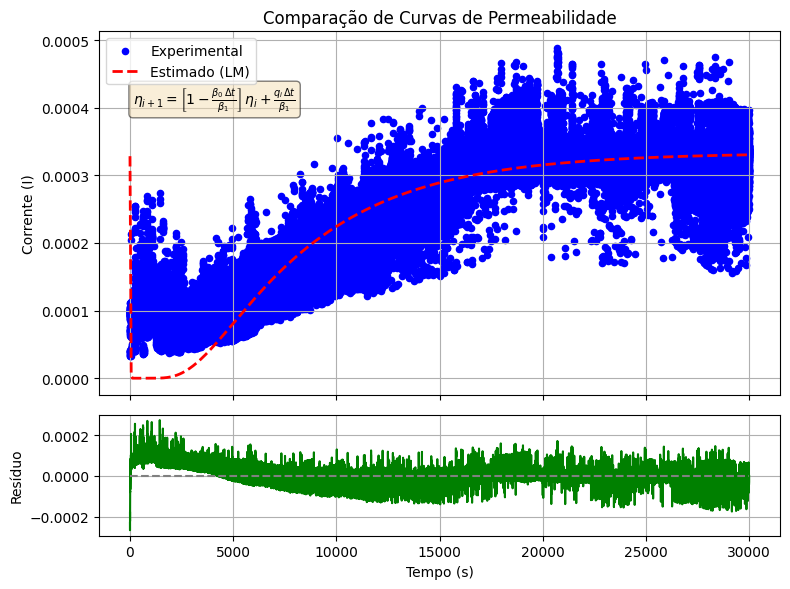

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# 1) Parâmetros do ensaio e modelo
L = 0.9        # espessura da amostra (mm)
N_TERMS = 20   # termos da série de Fourier

# 2) Carregamento dos dados experimentais (réplicas)
def load_and_concat(files):
    dfs = []
    for f in files:
        # usa regex de espaços múltiplos
        df = pd.read_csv(f, sep=r'\s+', usecols=[0,1], header=None, names=['tempo','I'])
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

files = [
    'Amostra 3.txt',
    'amostra 1.txt',
    'amostra 2.txt'
]
data = load_and_concat(files)

# 3) Curva média experimental
#    I_mean(t) = média das réplicas
df_mean = data.groupby('tempo', as_index=False)['I'].mean().rename(columns={'I':'I_mean'})
t = df_mean['tempo'].values
I_exp = df_mean['I_mean'].values

# 4) Modelo teórico de permeação (série de Fourier)
def I_model(params, t):
    I_ss, D = params
    series = np.zeros_like(t)
    for n in range(1, N_TERMS+1):
        alpha = (n**2 * np.pi**2 * D * t) / (L**2)
        series += (-1)**n * np.exp(-alpha)
    return I_ss * (1 + 2 * series)

# 5) Função de resíduos para ajuste LM
#    r_j = I_model(params, t_j) - I_exp(j)
def residuals(params, t, I_obs):
    return I_model(params, t) - I_obs

# 6) Estimativas iniciais de parâmetros
I0 = I_exp.max()
t_lag_idx = np.argmax(I_exp >= 0.63 * I0)
t_lag = t[t_lag_idx] if t_lag_idx > 0 else t[1]
D0 = L**2 / (6 * (t_lag + 1e-6))
x0 = [I0, D0]

# 7) Ajuste pelo método de Levenberg–Marquardt
res = least_squares(residuals, x0, args=(t, I_exp), method='lm')
I_ss_fit, D_fit = res.x
print(f"Parâmetros estimados pelo LM:\n I_ss = {I_ss_fit:.4f}\n Dap = {D_fit:.4e} mm²/s")

# 8) Geração da curva estimada
t_fit = np.linspace(t.min(), t.max(), 500)
I_est = I_model([I_ss_fit, D_fit], t_fit)

# 9) Cálculo dos resíduos em pontos experimentais
resid = I_exp - I_model([I_ss_fit, D_fit], t)

# 10) Plot comparativo e resíduos
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={'height_ratios':[3,1]}
)

# Painel superior: curvas Experimental vs Estimada
ax1.scatter(t, I_exp, c='blue', s=20, label='Experimental')
ax1.plot(t_fit, I_est, '--', color='red', linewidth=2, label='Estimado (LM)')
ax1.set_ylabel('Corrente (I)')
ax1.set_title('Comparação de Curvas de Permeabilidade')
ax1.legend()
ax1.grid(True)

# Inserir equação do slide com sintaxe compatível
eq_text = r'$\eta_{i+1} = \left[1 - \frac{\beta_0\,\Delta t}{\beta_1}\right]\,\eta_i + \frac{q_i\,\Delta t}{\beta_1}$'
ax1.text(
    0.05, 0.8, eq_text,
    transform=ax1.transAxes,
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

# Painel inferior: resíduos
ax2.plot(t, resid, '-', color='green')
ax2.hlines(0, t.min(), t.max(), colors='gray', linestyles='dashed')
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('Resíduo')
ax2.grid(True)

plt.tight_layout()
plt.show()


# Documentação do Algoritmo de Ajuste Inverso via Levenberg–Marquardt

## 1. Parâmetros do Ensaio e Modelo

* **Espessura da amostra**: $L = 0{,}9$ mm.
* **Número de termos na série**: $N_{\mathrm{TERMS}} = 20$.

Esses parâmetros definem a solução analítica truncada da equação de difusão unidimensional para fluxo de gás.

---

## 2. Carregamento dos Dados Experimentais

```python
def load_and_concat(files):
    dfs = []
    for f in files:
        df = pd.read_csv(f, sep=r'\s+', usecols=[0,1], header=None, names=['tempo','I'])
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)
```

* **Leitura** de múltiplas réplicas em TXT com colunas `tempo` e `I`.
* **Concatenação** em um único `DataFrame`.

---

## 3. Curva Média Experimental

A cada instante $t_j$, calcula-se:

$$
I_{\mathrm{mean}}(t_j) = \frac{1}{n_j}\sum_{i=1}^{n_j} I_{i,j},
$$

onde $n_j$ é o número de medições em $t_j$.

```python
df_mean = data.groupby('tempo', as_index=False)['I'].mean().rename(columns={'I':'I_mean'})
t = df_mean['tempo'].values
I_exp = df_mean['I_mean'].values
```

---

## 4. Modelo Teórico de Permeação

A solução analítica da EDP de difusão em regime transiente, com condição de contorno escalão em uma face de lâmina de espessura $L$, é:

$$
I(t) = I_{ss}\Bigl[1 + 2\sum_{n=1}^{\infty}(-1)^n e^{-\frac{n^2\pi^2 D\,t}{L^2}}\Bigr].
$$

No código, truncamos em $N_{\mathrm{TERMS}}$:

```python
def I_model(params, t):
    I_ss, D = params
    series = 0
    for n in range(1, N_TERMS+1):
        alpha = \frac{n^2\pi^2 D\,t}{L^2}
        series += (-1)**n * np.exp(-alpha)
    return I_ss * (1 + 2*series)
```

---

## 5. Função de Resíduos

Definimos o vetor de resíduos:

$$
r_j(\theta) = I_{\text{model}}(\theta, t_j) - I_{\text{exp}}(t_j),
$$

onde $\theta=(I_{ss},D)$.

```python
def residuals(params, t, I_obs):
    return I_model(params, t) - I_obs
```

---

## 6. Estimativas Iniciais de Parâmetros

* **Estimativa de $I_{ss}$**: máximo observado nas réplicas: $I_0 = \max I_{\mathrm{exp}}$.
* **Time‑lag**: instante $t_\tau$ onde $I_{\mathrm{exp}}$ atinge 63 % de $I_0$.
* **Estimativa de $D$** via aproximação: $t_\tau \approx \frac{L^2}{6 D}$ ⇒ $D_0 = \frac{L^2}{6 t_\tau}$.

```python
I0 = I_exp.max()
t_lag_idx = np.argmax(I_exp >= 0.63*I0)
t_lag = t[t_lag_idx] + \varepsilon
D0 = L**2/(6*t_lag)
x0 = [I0, D0]
```

---

## 7. Ajuste pelo Método de Levenberg–Marquardt

O LM resolve iterativamente o problema de mínimos quadrados não lineares:

$$
\bigl(J^T J + \lambda\,\mathrm{diag}(J^T J)\bigr)\Delta\theta = -J^T r,
$$

atualizando $\theta_{k+1} = \theta_k + \Delta\theta$.

```python
res = least_squares(residuals, x0, args=(t, I_exp), method='lm')
I_ss_fit, D_fit = res.x
```

---

## 8. Geração da Curva Estimada

```python
t_fit = np.linspace(t.min(), t.max(), 500)
I_est = I_model([I_ss_fit, D_fit], t_fit)
```

Avaliação contínua do modelo final.

---

## 9. Resíduos Finais

$$
\mathrm{resid}_j = I_{\mathrm{exp}}(t_j) - I_{\mathrm{model}}(t_j;\theta^*).
$$

```python
resid = I_exp - I_model([I_ss_fit, D_fit], t)
```

---

## 10. Plotagem

* **Painel superior**: pontos experimentais e linha do modelo estimado.
* **Equação do avanço** (proveniente de modelo em FD, adicionada como texto):

  $$
    \eta_{i+1} = \left[1 - \frac{\beta_0\,\Delta t}{\beta_1}\right]\eta_i + \frac{q_i\,\Delta t}{\beta_1}.
  $$
* **Painel inferior**: gráfico dos resíduos.

```python
# Criação de subplots...
ax1.scatter(...)
ax1.plot(...)
ax1.text(...)
ax2.plot(...)
```

---

### Fórmulas Principais

1. **Média**: $I_{\mathrm{mean}} = \frac1{n}\sum I_i$.
2. **Solução analítica**: $I(t) = I_{ss}[1 + 2\sum(-1)^n e^{-n^2\pi^2 D t/L^2}]$.
3. **Resíduos**: $r = I_{model}-I_{obs}$.
4. **LM**: $(J^TJ+\lambda\mathrm{diag}(J^TJ))\Delta\theta = -J^T r$.
5. **Time‑lag**: $t_\tau \approx L^2/(6D)$.

---

*Fim da Documentação.*


In [6]:
!pip install python-docx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 5.8 MB/s eta 0:00:00


# Nova seção